In [1]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.channel import *
from src.grouping import *

import numpy as np

In [2]:
M = 1000
Q = 250

h_BI, h_IU = generate_channels(M)

cascaded = h_BI * h_IU

phase_groups = phase_grouping(
    cascaded,
    Q
)

groups_70 = sparse_phase_grouping(
    cascaded,
    Q,
    keep_ratio=0.7
)

groups_80 = sparse_phase_grouping(
    cascaded,
    Q,
    keep_ratio=0.8
)

groups_90 = sparse_phase_grouping(
    cascaded,
    Q,
    keep_ratio=0.9
)

phase_gain = abs(
    grouped_channel(
        h_BI,
        h_IU,
        phase_groups
    )
)**2

gain_70 = abs(
    grouped_channel(
        h_BI,
        h_IU,
        groups_70
    )
)**2

gain_80 = abs(
    grouped_channel(
        h_BI,
        h_IU,
        groups_80
    )
)**2

gain_90 = abs(
    grouped_channel(
        h_BI,
        h_IU,
        groups_90
    )
)**2

print("Phase :", phase_gain)
print("70% :", gain_70)
print("80% :", gain_80)
print("90% :", gain_90)

Phase : 614312.3405575283
70% : 510790.91174086276
80% : 560849.4112987128
90% : 597441.1696852443


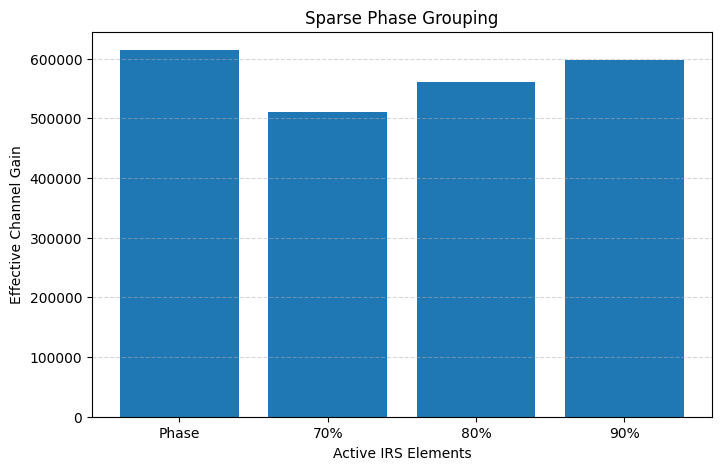

In [3]:
import matplotlib.pyplot as plt

labels = [
    "Phase",
    "70%",
    "80%",
    "90%"
]

gains = [
    phase_gain,
    gain_70,
    gain_80,
    gain_90
]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    gains
)

plt.ylabel(
    "Effective Channel Gain"
)

plt.xlabel(
    "Active IRS Elements"
)

plt.title(
    "Sparse Phase Grouping"
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.savefig(
    "../results/figures/sparse_phase_grouping.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
magnitude = np.abs(cascaded)

energy = magnitude**2

sorted_energy = np.sort(
    energy
)[::-1]

cumulative = np.cumsum(
    sorted_energy
)

target_energy = (
    0.95 * np.sum(energy)
)

required_elements = np.argmax(
    cumulative >= target_energy
) + 1

print(
    "Elements Needed:",
    required_elements
)

print(
    "Percentage:",
    required_elements / len(cascaded) * 100
)

Elements Needed: 558
Percentage: 55.800000000000004
